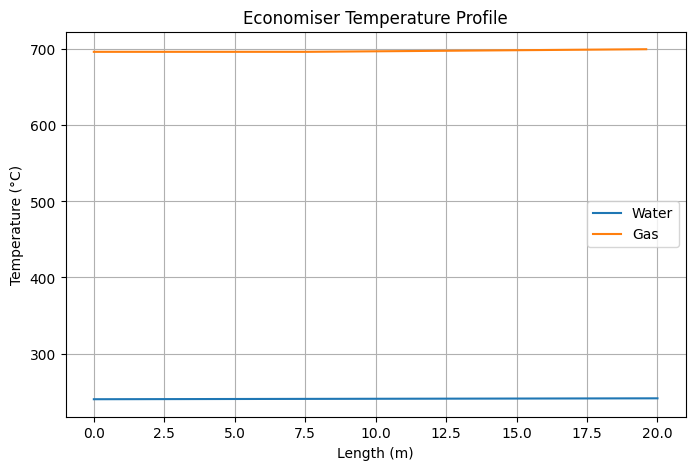

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# PARAMETERS
# =========================================================

N = 50
L = 20.0
dx = L / N

# Geometry
d_in = 0.022
d_out = 0.032
delta_wall = (d_out - d_in) / 2
delta_ash = 0.001

# Flow
m_s = 50.0
m_g = 60.0

cp_s = 4200
cp_g = 1100

# Inlet conditions
Ts_inlet = 240 + 273.15
Tg_inlet = 700 + 273.15

# =========================================================
# PROPERTY MODELS
# =========================================================

def k_wall(T):
    T_C = T - 273.15
    return 35.76 - 6.012e-7 * T_C**2.5  # paper Eq (1)

def k_g(T): return 0.04
def Pr_g(T): return 0.7

def k_s(T): return 0.6
def Pr_s(T): return 2.0

# =========================================================
# HEAT TRANSFER
# =========================================================

def h_gas(Tg):
    Re = 1e5
    Pr = Pr_g(Tg)
    Nu = 0.196 * Re**0.674 * Pr**0.44
    return Nu * k_g(Tg) / d_out

def h_water(Ts):
    Re = 5e4
    Pr = Pr_s(Ts)

    f = (1.82*np.log10(Re)-1.64)**(-2)
    Nu = (f/8)*(Re-1000)*Pr / (1+12.7*np.sqrt(f/8)*(Pr**(2/3)-1))

    return Nu * k_s(Ts) / d_in

# =========================================================
# NTU
# =========================================================

def NTU_s(h):
    return np.pi * d_in * h * dx / (m_s * cp_s)

def NTU_g(h):
    return np.pi * (d_out + delta_ash) * h * dx / (m_g * cp_g)

# =========================================================
# ARRAYS
# =========================================================

Ts = np.zeros(N+1)
Ts[0] = Ts_inlet

Tg_in = np.full(N, Tg_inlet)   # gas entering each element
Tg_out = np.zeros(N)

# =========================================================
# OUTER ITERATION (coupling)
# =========================================================

for outer in range(30):

    Ts[0] = Ts_inlet  # reset inlet each sweep

    for i in range(N):

        Ts_i = Ts[i]
        Tg_i = Tg_in[i]

        # initial guesses
        Tw1 = Ts_i + 20
        Tw2 = Ts_i + 30
        Tw3 = Tg_i - 20

        # -------------------------------
        # WALL ITERATION (Gauss-Seidel)
        # -------------------------------
        for _ in range(100):

            hs = h_water(Ts_i)
            hg = h_gas(Tg_i)

            kw1 = k_wall(Tw1)
            kw2 = k_wall(Tw2)

            # inner wall
            Tw1_new = (hs*Ts_i + kw2*Tw2/delta_wall) / (hs + kw2/delta_wall)

            # middle wall
            Tw2_new = (
                kw1*Tw1_new/delta_wall + kw2*Tw3/delta_wall
            ) / (kw1/delta_wall + kw2/delta_wall)

            # outer wall
            Tw3_new = (hg*Tg_i + kw2*Tw2_new/delta_wall) / (hg + kw2/delta_wall)

            if max(abs(Tw1_new-Tw1), abs(Tw2_new-Tw2), abs(Tw3_new-Tw3)) < 1e-6:
                break

            Tw1, Tw2, Tw3 = Tw1_new, Tw2_new, Tw3_new

        # -------------------------------
        # FLUID UPDATE
        # -------------------------------
        Ns = NTU_s(hs)
        Ng = NTU_g(hg)

        Ts_out = Tw1 - (Tw1 - Ts_i)*np.exp(-Ns)
        Tg_out[i] = Tw3 - (Tw3 - Tg_i)*np.exp(-Ng)

        Ts[i+1] = Ts_out

    # -------------------------------
    # COUNTERCURRENT UPDATE
    # -------------------------------
    Tg_in[:-1] = Tg_out[1:]
    Tg_in[-1] = Tg_inlet  # boundary condition

# =========================================================
# RESULTS
# =========================================================

x = np.linspace(0, L, N+1)

plt.figure(figsize=(8,5))
plt.plot(x, Ts - 273.15, label="Water")
plt.plot(x[:-1], Tg_in - 273.15, label="Gas")
plt.xlabel("Length (m)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid()
plt.title("Economiser Temperature Profile")
plt.show()

print